# 🌿 Betel Leaf Disease Detection — Early Fusion AlexNet
**CSE 438 Group-4 | Fusion Method: Early Fusion (RGB + Edge Channel Concatenation)**

---
## Pipeline Overview
| Step | Description |
|------|-------------|
| Step 1  | Install & Import Libraries |
| Step 2  | Dataset Download & Directory Setup |
| Step 3  | Data Exploration & Class Distribution |
| Step 4  | Data Augmentation & Early Fusion Transform |
| Step 5  | Dataset & DataLoader Creation |
| Step 6  | Early Fusion Model Building (AlexNet) |
| Step 7  | Training Loop with Validation |
| Step 8  | Training Curves Visualization |
| Step 9  | Final Test Evaluation & Metrics |
| Step 10 | Confusion Matrix & Per-Class Report |

> **Backbone:** AlexNet (pretrained ImageNet)  
> **Fusion Type:** Early Fusion — RGB (3ch) + Sobel Edge Map (1ch) → 4-channel input  
> **Key change (PDF Step 3.3):** AlexNet's first conv: `features[0]` = Conv2d(3,64,11,stride=4,padding=2).  
> **Note:** AlexNet is very lightweight (~60M params) — fastest training.


---
## ✅ Step 1 — Install & Import Libraries

In [1]:
import subprocess, sys
packages = ["timm", "scikit-learn", "matplotlib", "seaborn", "Pillow", "torchvision"]
for pkg in packages:
    result = subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"],
                            capture_output=True, text=True)
    print(f"[OK] {pkg}" if result.returncode == 0 else f"[FAIL] {pkg}: {result.stderr[:80]}")
print("\n✅ All packages ready!")

import os, random, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image, ImageFilter
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
import torchvision.models as tv_models
import timm

from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, precision_score, recall_score)
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n🖥️  Device  : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"   GPU     : {torch.cuda.get_device_name(0)}")
    print(f"   VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"   PyTorch : {torch.__version__}")
print(f"   timm    : {timm.__version__}")


[OK] timm
[OK] scikit-learn
[OK] matplotlib
[OK] seaborn
[OK] Pillow
[OK] torchvision

✅ All packages ready!

🖥️  Device  : cuda
   GPU     : Tesla T4
   VRAM    : 15.6 GB
   PyTorch : 2.10.0+cu128
   timm    : 1.0.25


---
## ✅ Step 2 — Dataset Download & Directory Setup

Dataset source: https://data.mendeley.com/datasets/vpzkntzjty/1  
> On Kaggle: **Add Data → Datasets** → search `"Comprehensive Betel Leaf Disease"` → add it.  
> **Input size for AlexNet: 224×224**

In [2]:
CLASS_NAMES  = ["Healthy_Leaf", "Leaf_Rot", "Leaf_Spot"]
DATASET_ROOT = None

for root in ["/kaggle/input", "./data", "."]:
    for dirpath, dirnames, _ in os.walk(root):
        if "Original_Dataset" in dirnames:
            DATASET_ROOT = Path(dirpath) / "Original_Dataset"
            print(f"✅ Found Original_Dataset at: {DATASET_ROOT}")
            break
    if DATASET_ROOT: break

if DATASET_ROOT is None:
    print("⚠️  Original_Dataset not found — creating synthetic demo data...")
    DATASET_ROOT = Path("/kaggle/working/demo_dataset")
    for split in ["train", "val", "test"]:
        for cls in CLASS_NAMES:
            (DATASET_ROOT / split / cls).mkdir(parents=True, exist_ok=True)
            for i in range(30 if split == "train" else 10):
                img = Image.fromarray(np.random.randint(50, 200, (224, 224, 3), dtype=np.uint8))
                img.save(DATASET_ROOT / split / cls / f"img_{i:04d}.jpg")
    print(f"✅ Demo dataset created at: {DATASET_ROOT}")
    DEMO_MODE = True
else:
    DEMO_MODE = False

if not DEMO_MODE:
    from sklearn.model_selection import train_test_split
    import shutil
    SPLIT_ROOT = Path("/kaggle/working/split_dataset")
    if not SPLIT_ROOT.exists():
        print("\n📁 Creating train/val/test splits (70 / 15 / 15)...")
        for cls in CLASS_NAMES:
            all_imgs = (sorted((DATASET_ROOT / cls).glob("*.jpg")) +
                        sorted((DATASET_ROOT / cls).glob("*.png")) +
                        sorted((DATASET_ROOT / cls).glob("*.jpeg")))
            tr, temp = train_test_split(all_imgs, test_size=0.30, random_state=SEED)
            vl, te   = train_test_split(temp,     test_size=0.50, random_state=SEED)
            for split_name, imgs in [("train", tr), ("val", vl), ("test", te)]:
                dest = SPLIT_ROOT / split_name / cls
                dest.mkdir(parents=True, exist_ok=True)
                for src in imgs: shutil.copy(src, dest / src.name)
            print(f"   {cls:<15} → train:{len(tr):4d}  val:{len(vl):4d}  test:{len(te):4d}")
        print("✅ Splits ready!")
    DATASET_ROOT = SPLIT_ROOT

print("\n📊 Dataset Summary:")
for split in ["train", "val", "test"]:
    total = sum(len(list((DATASET_ROOT / split / c).glob("*.*")))
                for c in CLASS_NAMES if (DATASET_ROOT / split / c).exists())
    print(f"   {split:>5}: {total:5d} images")

IMG_SIZE    = 224
NUM_CLASSES = len(CLASS_NAMES)
BATCH_SIZE  = 64
NUM_EPOCHS  = 20
LR          = 1e-4
NUM_WORKERS = 2

print(f"\n⚙️  Config: IMG={IMG_SIZE}  Classes={NUM_CLASSES}  "
      f"Batch={BATCH_SIZE}  Epochs={NUM_EPOCHS}  LR={LR}")


✅ Found Original_Dataset at: /kaggle/input/datasets/mikeafridi/cse-438-group-4/Comprehensive Betel Leaf Disease Dataset for Advanced Pathology Research/Betel Leaf Dataset/Betel Leaf Dataset/Betel Leaf Dataset/Original_Dataset

📁 Creating train/val/test splits (70 / 15 / 15)...
   Healthy_Leaf    → train: 756  val: 162  test: 162
   Leaf_Rot        → train: 188  val:  40  test:  41
   Leaf_Spot       → train: 481  val: 103  test: 104
✅ Splits ready!

📊 Dataset Summary:
   train:  1425 images
     val:   305 images
    test:   307 images

⚙️  Config: IMG=224  Classes=3  Batch=64  Epochs=20  LR=0.0001


---
## ✅ Step 3 — Data Exploration & Class Distribution

📊 Class Distribution Table
Split         test  train  val
Class                         
Healthy_Leaf   162    756  162
Leaf_Rot        41    188   40
Leaf_Spot      104    481  103


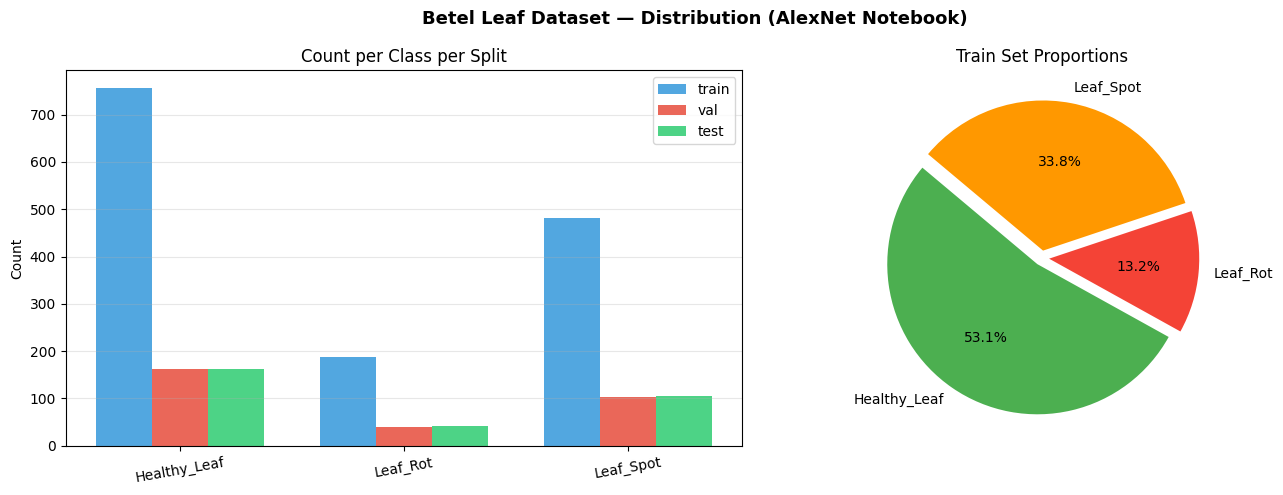

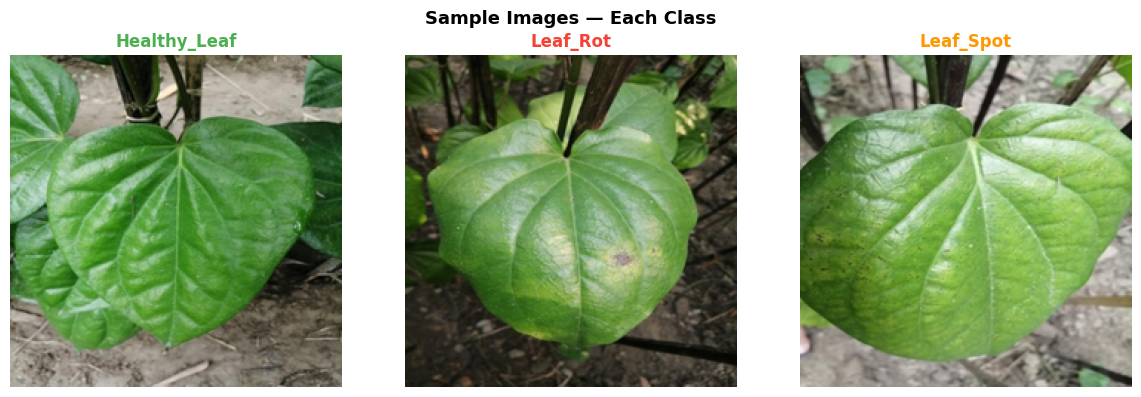

✅ Step 3 complete.


In [3]:
MODEL_NAME = "AlexNet"
PREFIX = "alexnet"

records = []
for split in ["train", "val", "test"]:
    for cls in CLASS_NAMES:
        folder = DATASET_ROOT / split / cls
        if folder.exists():
            imgs = (list(folder.glob("*.jpg")) + list(folder.glob("*.png")) +
                    list(folder.glob("*.jpeg")))
            records.append({"Split": split, "Class": cls, "Count": len(imgs)})

df_dist = pd.DataFrame(records)
print("📊 Class Distribution Table")
print(df_dist.pivot(index="Class", columns="Split", values="Count").fillna(0).astype(int))

colors = ["#4CAF50", "#F44336", "#FF9800"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Betel Leaf Dataset — Distribution ({MODEL_NAME} Notebook)",
             fontsize=13, fontweight="bold")

ax = axes[0]
x = np.arange(len(CLASS_NAMES)); w = 0.25
for i, (split, col) in enumerate(zip(["train", "val", "test"],
                                      ["#3498db", "#e74c3c", "#2ecc71"])):
    vals = [df_dist[(df_dist.Split == split) & (df_dist.Class == c)]["Count"].sum()
            for c in CLASS_NAMES]
    ax.bar(x + i * w, vals, w, label=split, color=col, alpha=0.85)
ax.set_xticks(x + w); ax.set_xticklabels(CLASS_NAMES, rotation=10)
ax.set_title("Count per Class per Split"); ax.set_ylabel("Count")
ax.legend(); ax.grid(axis="y", alpha=0.3)

ax2 = axes[1]
train_counts = [df_dist[(df_dist.Split == "train") & (df_dist.Class == c)]["Count"].sum()
                for c in CLASS_NAMES]
ax2.pie(train_counts, labels=CLASS_NAMES, colors=colors, autopct="%1.1f%%",
        startangle=140, explode=[0.05] * 3)
ax2.set_title("Train Set Proportions")
plt.tight_layout()
plt.savefig(f"/kaggle/working/{PREFIX}_step3_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

fig2, axes2 = plt.subplots(1, 3, figsize=(12, 4))
fig2.suptitle("Sample Images — Each Class", fontsize=13, fontweight="bold")
for ax, cls, color in zip(axes2, CLASS_NAMES, colors):
    folder = DATASET_ROOT / "train" / cls
    sample = list(folder.glob("*.*"))[0]
    ax.imshow(Image.open(sample).resize((224, 224)))
    ax.set_title(cls, color=color, fontweight="bold"); ax.axis("off")
plt.tight_layout()
plt.savefig(f"/kaggle/working/{PREFIX}_step3_samples.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Step 3 complete.")


---
## ✅ Step 4 — Data Augmentation & Early Fusion Transform

**Early Fusion Strategy:**  
- Channel 0-2 → Normalized RGB (ImageNet mean/std)  
- Channel 3   → Sobel Edge Map (structural texture info)  
- Concatenate → **4-channel tensor [B, 4, 224, 224]**  

Augmentation (train only): RandomFlip, RandomRotation ±15°, ColorJitter — as per PDF Phase 1.

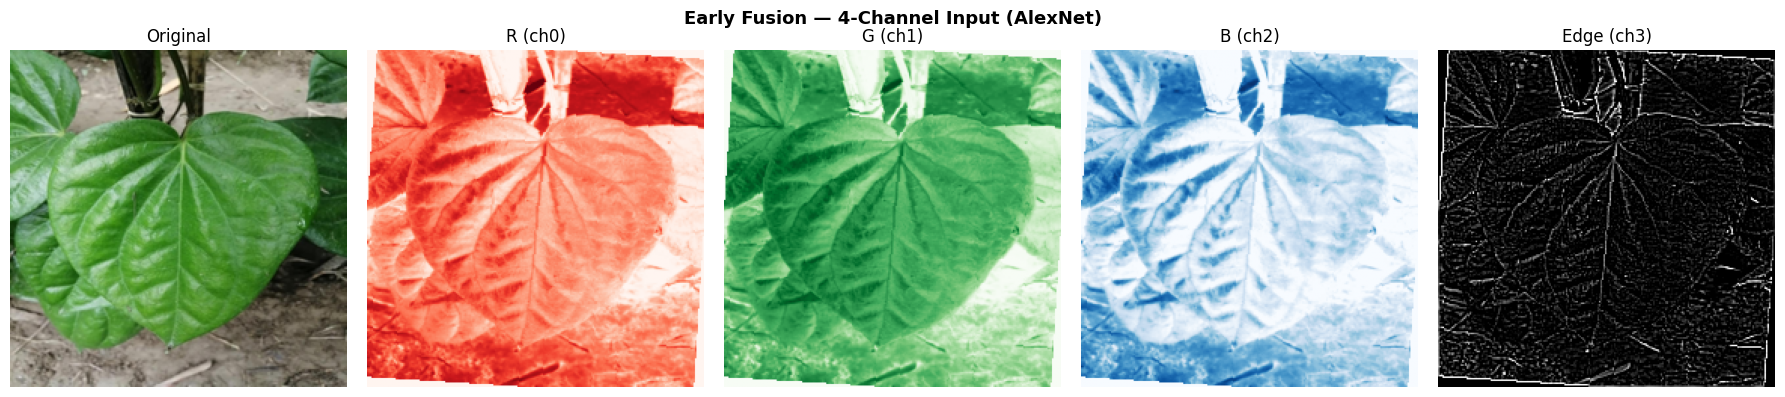

✅ Step 4 complete — Fused tensor shape: torch.Size([4, 224, 224])  (4 × 224 × 224)


In [4]:
# Early Fusion Transform ─ same logic for all models
# Channel 0-2 : Normalized RGB
# Channel 3   : Sobel Edge Map (structural texture info)
# Concatenated → [B, 4, IMG_SIZE, IMG_SIZE]

MEAN_RGB  = [0.485, 0.456, 0.406]
STD_RGB   = [0.229, 0.224, 0.225]
MEAN_EDGE = [0.5]
STD_EDGE  = [0.5]

class EarlyFusionTransform:
    """
    Early Fusion: RGB (3ch) + Sobel Edge (1ch) → 4-channel tensor.
    PDF Phase 1: rotate ±15°, flip, brightness/contrast augmentation (train only).
    """
    def __init__(self, is_train=True):
        self.is_train  = is_train
        self.resize    = transforms.Resize((IMG_SIZE, IMG_SIZE))
        self.to_tensor = transforms.ToTensor()
        self.aug = transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.2),
            transforms.RandomRotation(degrees=15),
            transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
            transforms.RandomGrayscale(p=0.05),
        ])
        self.norm_rgb  = transforms.Normalize(MEAN_RGB, STD_RGB)
        self.norm_edge = transforms.Normalize(MEAN_EDGE, STD_EDGE)

    def _edge_channel(self, pil_img):
        edge_t = self.to_tensor(pil_img.convert("L").filter(ImageFilter.FIND_EDGES))
        return self.norm_edge(edge_t)   # [1, H, W]

    def __call__(self, pil_img):
        img    = self.resize(pil_img)
        if self.is_train: img = self.aug(img)
        rgb_t  = self.norm_rgb(self.to_tensor(img))   # [3, H, W]
        edge_t = self._edge_channel(img)               # [1, H, W]
        return torch.cat([rgb_t, edge_t], dim=0)       # [4, H, W]


train_transform = EarlyFusionTransform(is_train=True)
val_transform   = EarlyFusionTransform(is_train=False)

# Visualize 4-channel fusion
sample_path = list((DATASET_ROOT / "train" / CLASS_NAMES[0]).glob("*.*"))[0]
sample_pil  = Image.open(sample_path).convert("RGB")
fused       = train_transform(sample_pil)

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle(f"Early Fusion — 4-Channel Input (AlexNet)", fontsize=13, fontweight="bold")
axes[0].imshow(sample_pil.resize((224, 224)))
axes[0].set_title("Original"); axes[0].axis("off")
for i, (name, cmap) in enumerate(zip(
        ["R (ch0)", "G (ch1)", "B (ch2)", "Edge (ch3)"],
        ["Reds", "Greens", "Blues", "gray"])):
    axes[i + 1].imshow(fused[i].numpy(), cmap=cmap)
    axes[i + 1].set_title(name); axes[i + 1].axis("off")
plt.tight_layout()
plt.savefig(f"/kaggle/working/alexnet_step4_fusion_channels.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"✅ Step 4 complete — Fused tensor shape: {fused.shape}  (4 × {IMG_SIZE} × {IMG_SIZE})")


---
## ✅ Step 5 — Dataset & DataLoader Creation

In [5]:
class BetelLeafFusionDataset(Dataset):
    def __init__(self, root_dir, class_names, transform=None):
        self.class_names  = class_names
        self.class_to_idx = {c: i for i, c in enumerate(class_names)}
        self.transform    = transform
        self.samples      = []
        for cls in class_names:
            folder = Path(root_dir) / cls
            if not folder.exists(): continue
            for ext in ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.PNG"]:
                for p in sorted(folder.glob(ext)):
                    self.samples.append((str(p), self.class_to_idx[cls]))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        try:    img = Image.open(path).convert("RGB")
        except: img = Image.fromarray(np.zeros((224, 224, 3), dtype=np.uint8))
        if self.transform: img = self.transform(img)
        return img, label


train_ds = BetelLeafFusionDataset(DATASET_ROOT / "train", CLASS_NAMES, train_transform)
val_ds   = BetelLeafFusionDataset(DATASET_ROOT / "val",   CLASS_NAMES, val_transform)
test_ds  = BetelLeafFusionDataset(DATASET_ROOT / "test",  CLASS_NAMES, val_transform)
print(f"📦 Sizes → Train: {len(train_ds)}  Val: {len(val_ds)}  Test: {len(test_ds)}")

# WeightedRandomSampler — handles class imbalance (PDF Phase 1)
labels_train = [s[1] for s in train_ds.samples]
class_counts = Counter(labels_train)
weights      = [1.0 / class_counts[l] for l in labels_train]
sampler      = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

batch_imgs, batch_labels = next(iter(train_loader))
print(f"\n🔍 Batch check:")
print(f"   Image tensor : {batch_imgs.shape}  (B × 4 × H × W)")
print(f"   Labels       : {batch_labels[:8].tolist()}")
print(f"   Value range  : [{batch_imgs.min():.3f}, {batch_imgs.max():.3f}]")
print("\n✅ Step 5 complete — DataLoaders ready!")


📦 Sizes → Train: 1425  Val: 305  Test: 307

🔍 Batch check:
   Image tensor : torch.Size([64, 4, 224, 224])  (B × 4 × H × W)
   Labels       : [1, 1, 1, 0, 1, 1, 0, 1]
   Value range  : [-2.118, 2.640]

✅ Step 5 complete — DataLoaders ready!


---
## ✅ Step 6 — Early Fusion Model Building (AlexNet)

**PDF Steps 3.2 & 3.3:**  
- Load pretrained AlexNet  
- Modify first conv/patch-embed to accept 4 channels (RGB + Edge)  
- Initialize 4th channel weights = mean of pretrained RGB weights  
- Replace classification head for 3 output classes  
- Loss: CrossEntropyLoss | Optimizer: AdamW | Scheduler: CosineAnnealing

In [6]:
# ── Early Fusion AlexNet ─────────────────────────────────────────────────
# AlexNet first conv: features[0] = Conv2d(3, 64, kernel_size=11, stride=4, padding=2)
# PDF Step 3.3: modify features[0] to accept 4 input channels

class EarlyFusionAlexNet(nn.Module):
    """
    Early Fusion AlexNet:
    - features[0] Conv2d(3→4, 64, kernel_size=11, stride=4, padding=2)
    - Pretrained RGB weights preserved; edge channel = mean of RGB weights
    - Classifier: Dropout → Linear(9216, 4096) → ReLU → Dropout → Linear(4096, 4096)
                  → ReLU → Linear(4096, num_classes)
    """
    def __init__(self, num_classes=3, dropout=0.5):
        super().__init__()
        self.backbone = tv_models.alexnet(weights=tv_models.AlexNet_Weights.IMAGENET1K_V1)

        # Modify first conv layer (PDF Step 3.3)
        old_conv = self.backbone.features[0]   # Conv2d(3, 64, 11, stride=4, padding=2)
        new_conv = nn.Conv2d(4, old_conv.out_channels,
                             old_conv.kernel_size, old_conv.stride, old_conv.padding)
        with torch.no_grad():
            new_conv.weight[:, :3, :, :] = old_conv.weight
            new_conv.weight[:, 3:4, :, :] = old_conv.weight.mean(dim=1, keepdim=True)
            if old_conv.bias is not None:
                new_conv.bias.copy_(old_conv.bias)
        self.backbone.features[0] = new_conv

        # Replace classifier (PDF Step 3.2)
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes)
        )

    def forward(self, x):   # x: [B, 4, 224, 224]
        return self.backbone(x)


model = EarlyFusionAlexNet(num_classes=NUM_CLASSES, dropout=0.5).to(DEVICE)

total_p     = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"🏗️  Model    : Early Fusion AlexNet")
print(f"   Input    : 4 channels (RGB + Edge map)")
print(f"   Output   : {NUM_CLASSES} classes")
print(f"   First conv: {model.backbone.features[0]}")
print(f"   Total params    : {total_p:,}")
print(f"   Trainable params: {trainable_p:,}")

model.eval()
with torch.no_grad():
    dummy = torch.randn(2, 4, IMG_SIZE, IMG_SIZE).to(DEVICE)
    out   = model(dummy)
print(f"\n✅ Forward pass OK — Output shape: {out.shape}")

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)
print(f"\n⚙️  Loss: CrossEntropyLoss | Optimizer: AdamW(lr={LR}) | Scheduler: CosineAnnealing")
print("\n✅ Step 6 complete — AlexNet model ready!")


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 177MB/s]


🏗️  Model    : Early Fusion AlexNet
   Input    : 4 channels (RGB + Edge map)
   Output   : 3 classes
   First conv: Conv2d(4, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
   Total params    : 57,023,875
   Trainable params: 57,023,875

✅ Forward pass OK — Output shape: torch.Size([2, 3])

⚙️  Loss: CrossEntropyLoss | Optimizer: AdamW(lr=0.0001) | Scheduler: CosineAnnealing

✅ Step 6 complete — AlexNet model ready!


---
## ✅ Step 7 — Training Loop with Validation

PDF **Phase 4**: train full pass → val loss + acc → save best checkpoint (lowest val loss)  
Early stopping with patience=7 to prevent overfitting.

In [7]:
CKPT_PATH = f"/kaggle/working/best_{PREFIX}_early_fusion.pth"

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = correct = total = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = correct = total = 0
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs     = model(imgs)
        total_loss += criterion(outputs, labels).item() * imgs.size(0)
        preds       = outputs.argmax(1)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return (total_loss / total, correct / total,
            np.array(all_preds), np.array(all_labels))


history = {"train_loss": [], "val_loss": [], "train_acc": [],
           "val_acc": [], "val_f1": [], "lr": []}
best_val_loss = float("inf")
best_val_acc  = 0.0
patience = 7; no_improve = 0

print(f"🚀 Training {MODEL_NAME} for {NUM_EPOCHS} epochs on {DEVICE}")
print(f"{'Epoch':>6} {'Train Loss':>11} {'Train Acc':>10} {'Val Loss':>10} "
      f"{'Val Acc':>9} {'Val F1':>8} {'LR':>10}")
print("-" * 72)

start_total = time.time()
for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc, val_preds, val_true = evaluate(model, val_loader, criterion, DEVICE)
    val_f1 = f1_score(val_true, val_preds, average="weighted", zero_division=0)
    cur_lr = optimizer.param_groups[0]["lr"]
    scheduler.step()

    for k, v in zip(["train_loss", "val_loss", "train_acc", "val_acc", "val_f1", "lr"],
                    [train_loss, val_loss, train_acc, val_acc, val_f1, cur_lr]):
        history[k].append(v)

    marker = ""
    if val_loss < best_val_loss:
        best_val_loss = val_loss; best_val_acc = val_acc
        torch.save({"epoch": epoch, "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "val_loss": val_loss, "val_acc": val_acc, "val_f1": val_f1}, CKPT_PATH)
        no_improve = 0; marker = " ✓ SAVED"
    else:
        no_improve += 1

    print(f"{epoch:>6} {train_loss:>11.4f} {train_acc*100:>9.2f}% "
          f"{val_loss:>10.4f} {val_acc*100:>8.2f}% "
          f"{val_f1:>8.4f} {cur_lr:>10.2e}  ({time.time()-t0:.1f}s){marker}")
    if no_improve >= patience:
        print(f"\n⏹️  Early stopping at epoch {epoch}"); break

print(f"\n✅ Training done in {(time.time()-start_total)/60:.1f} min")
print(f"   Best val loss: {best_val_loss:.4f}  |  Best val acc: {best_val_acc*100:.2f}%")


🚀 Training AlexNet for 20 epochs on cuda
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
------------------------------------------------------------------------
     1      0.9201     61.89%     0.6565    79.67%   0.8050   1.00e-04  (17.2s) ✓ SAVED
     2      0.6362     81.05%     0.6126    84.59%   0.8480   9.94e-05  (18.1s) ✓ SAVED
     3      0.5919     84.77%     0.5495    86.23%   0.8578   9.76e-05  (18.0s) ✓ SAVED
     4      0.5965     83.86%     0.5283    89.18%   0.8924   9.46e-05  (17.7s) ✓ SAVED
     5      0.5330     88.70%     0.5224    88.52%   0.8868   9.05e-05  (17.5s) ✓ SAVED
     6      0.5076     89.47%     0.4966    88.20%   0.8824   8.55e-05  (17.8s) ✓ SAVED
     7      0.4951     89.05%     0.5086    89.18%   0.8920   7.96e-05  (15.9s)
     8      0.4663     91.16%     0.4981    90.16%   0.9022   7.30e-05  (16.0s)
     9      0.4596     92.14%     0.5074    88.85%   0.8896   6.58e-05  (15.9s)
    10      0.4521     92.28%     0.4846    90.

---
## ✅ Step 8 — Training Curves Visualization

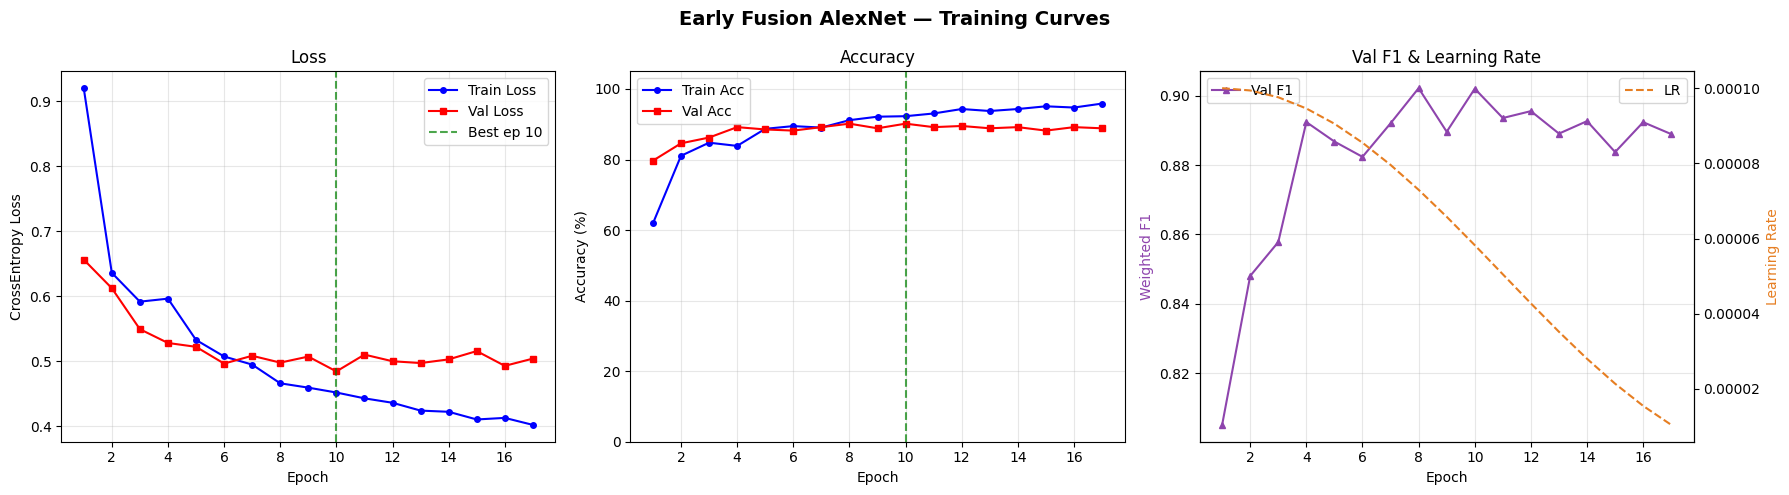


📈 Best epoch: 10 | Best val acc: 90.16% | Best val F1: 0.9022
✅ Step 8 complete.


In [8]:
epochs_ran = list(range(1, len(history["train_loss"]) + 1))
fig, axes  = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Early Fusion {MODEL_NAME} — Training Curves", fontsize=14, fontweight="bold")

ax = axes[0]
ax.plot(epochs_ran, history["train_loss"], "b-o", ms=4, label="Train Loss")
ax.plot(epochs_ran, history["val_loss"],   "r-s", ms=4, label="Val Loss")
best_ep = history["val_loss"].index(min(history["val_loss"])) + 1
ax.axvline(best_ep, color="green", linestyle="--", alpha=0.7, label=f"Best ep {best_ep}")
ax.set_title("Loss"); ax.set_xlabel("Epoch"); ax.set_ylabel("CrossEntropy Loss")
ax.legend(); ax.grid(alpha=0.3)

ax2 = axes[1]
ax2.plot(epochs_ran, [v * 100 for v in history["train_acc"]], "b-o", ms=4, label="Train Acc")
ax2.plot(epochs_ran, [v * 100 for v in history["val_acc"]],   "r-s", ms=4, label="Val Acc")
ax2.axvline(best_ep, color="green", linestyle="--", alpha=0.7)
ax2.set_title("Accuracy"); ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)")
ax2.set_ylim([0, 105]); ax2.legend(); ax2.grid(alpha=0.3)

ax3 = axes[2]
ax3.plot(epochs_ran, history["val_f1"], color="#8e44ad", marker="^", ms=4, label="Val F1")
ax3b = ax3.twinx()
ax3b.plot(epochs_ran, history["lr"], color="#e67e22", linestyle="--", label="LR")
ax3.set_title("Val F1 & Learning Rate"); ax3.set_xlabel("Epoch")
ax3.set_ylabel("Weighted F1", color="#8e44ad")
ax3b.set_ylabel("Learning Rate", color="#e67e22")
ax3.legend(loc="upper left"); ax3b.legend(loc="upper right")
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"/kaggle/working/{PREFIX}_step8_training_curves.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"\n📈 Best epoch: {best_ep} | Best val acc: {max(history['val_acc'])*100:.2f}% | "
      f"Best val F1: {max(history['val_f1']):.4f}")
print("✅ Step 8 complete.")


---
## ✅ Step 9 — Final Test Evaluation & Metrics

PDF **Phase 6**: Run best model on test set **once only** — report Accuracy, Weighted F1, Macro F1, Per-class F1.

In [9]:
ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
print(f"✅ Loaded best checkpoint — epoch {ckpt['epoch']}  "
      f"val_loss={ckpt['val_loss']:.4f}  val_acc={ckpt['val_acc']*100:.2f}%")

print("\n🔬 Running inference on test set...")
test_loss, test_acc, test_preds, test_true = evaluate(model, test_loader, criterion, DEVICE)

acc_pct      = test_acc * 100
weighted_f1  = f1_score(test_true, test_preds, average="weighted", zero_division=0)
macro_f1     = f1_score(test_true, test_preds, average="macro",    zero_division=0)
per_class_f1 = f1_score(test_true, test_preds, average=None,       zero_division=0)

print("\n" + "=" * 55)
print(f"  FINAL TEST RESULTS — Early Fusion {MODEL_NAME}")
print("=" * 55)
print(f"  {'Accuracy':<24}{acc_pct:.2f}%")
print(f"  {'Weighted F1':<24}{weighted_f1:.4f}")
print(f"  {'Macro F1':<24}{macro_f1:.4f}")
print(f"  {'Test Loss':<24}{test_loss:.4f}")
print("-" * 55)
print("  Per-Class F1:")
for cls, f1 in zip(CLASS_NAMES, per_class_f1):
    print(f"    {cls:<20} {f1:.4f}  {'█' * int(f1 * 30)}")
print("=" * 55)

print("\n📋 Classification Report:")
print(classification_report(test_true, test_preds, target_names=CLASS_NAMES, digits=4))

pd.DataFrame({
    "Metric": ["Accuracy", "Weighted F1", "Macro F1"] + [f"F1_{c}" for c in CLASS_NAMES],
    "Value":  [acc_pct/100, weighted_f1, macro_f1] + list(per_class_f1)
}).to_csv(f"/kaggle/working/{PREFIX}_step9_test_results.csv", index=False)
print("✅ Step 9 complete — results saved.")


✅ Loaded best checkpoint — epoch 10  val_loss=0.4846  val_acc=90.16%

🔬 Running inference on test set...

  FINAL TEST RESULTS — Early Fusion AlexNet
  Accuracy                91.21%
  Weighted F1             0.9121
  Macro F1                0.9054
  Test Loss               0.4667
-------------------------------------------------------
  Per-Class F1:
    Healthy_Leaf         0.9288  ███████████████████████████
    Leaf_Rot             0.8941  ██████████████████████████
    Leaf_Spot            0.8932  ██████████████████████████

📋 Classification Report:
              precision    recall  f1-score   support

Healthy_Leaf     0.9317    0.9259    0.9288       162
    Leaf_Rot     0.8636    0.9268    0.8941        41
   Leaf_Spot     0.9020    0.8846    0.8932       104

    accuracy                         0.9121       307
   macro avg     0.8991    0.9125    0.9054       307
weighted avg     0.9125    0.9121    0.9121       307

✅ Step 9 complete — results saved.


---
## ✅ Step 10 — Confusion Matrix & Per-Class Analysis

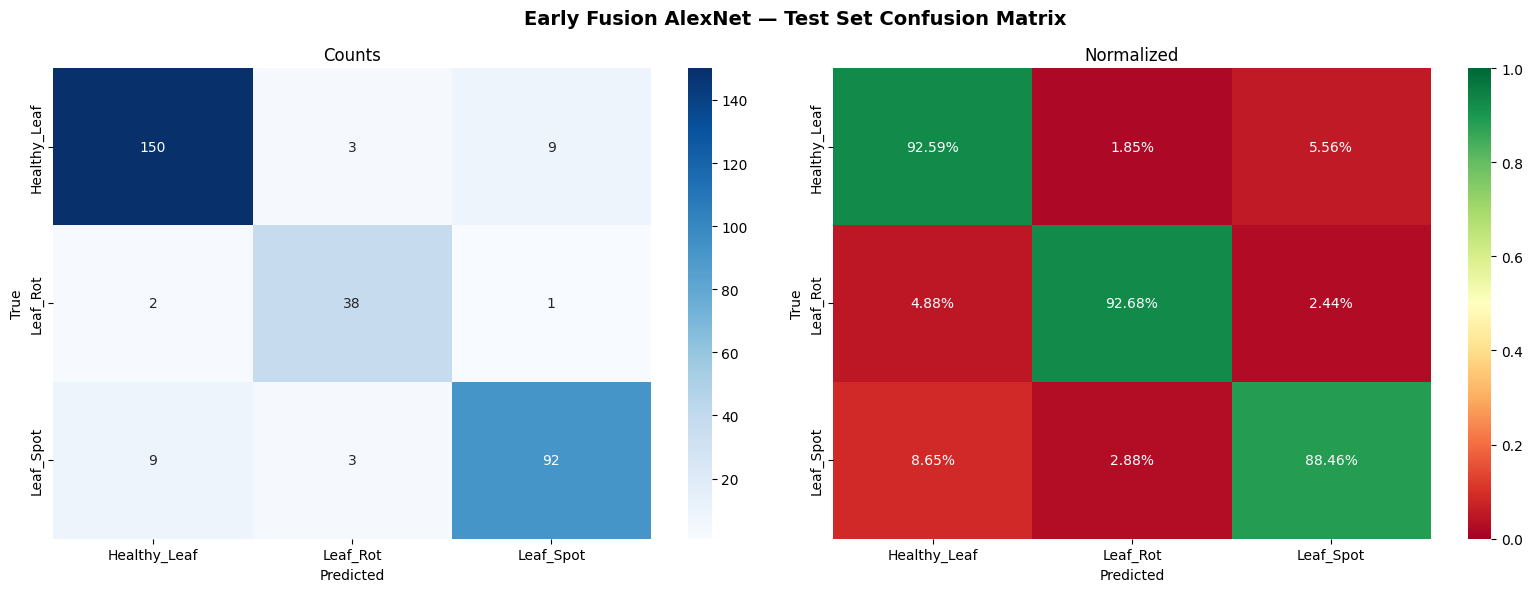

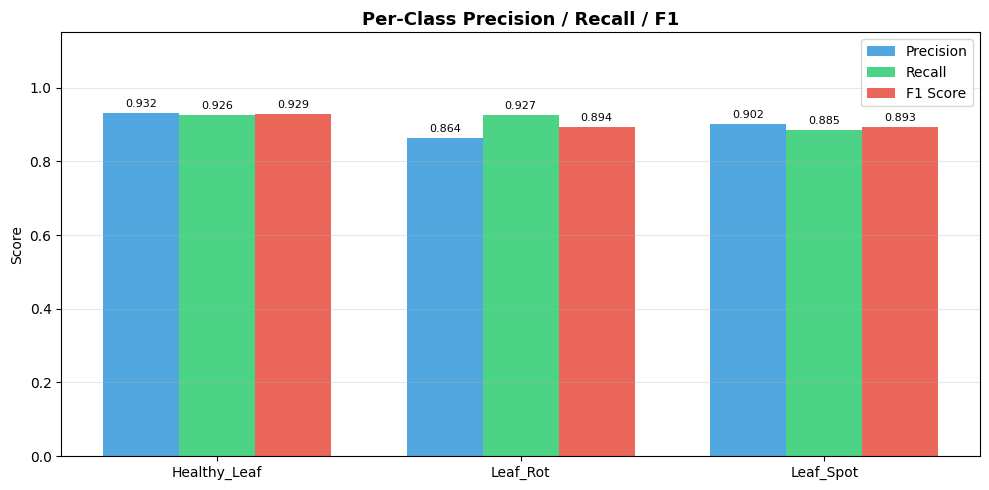


══════════════════════════════════════════════════════════════
  🌿 EARLY FUSION AlexNet — FINAL SUMMARY
══════════════════════════════════════════════════════════════
  Fusion Type  : Early Fusion (RGB + Edge channel)
  Input Shape  : [B, 4, 224, 224]
  Backbone     : AlexNet (pretrained ImageNet)
  Classes      : Healthy_Leaf, Leaf_Rot, Leaf_Spot
  Test Accuracy: 91.21%
  Weighted F1  : 0.9121
  Macro F1     : 0.9054
──────────────────────────────────────────────────────────────
    Healthy_Leaf        F1=0.9288  Prec=0.9317  Rec=0.9259
    Leaf_Rot            F1=0.8941  Prec=0.8636  Rec=0.9268
    Leaf_Spot           F1=0.8932  Prec=0.9020  Rec=0.8846
──────────────────────────────────────────────────────────────
  Saved files:
    ✓ /kaggle/working/alexnet_step3_distribution.png
    ✓ /kaggle/working/alexnet_step4_fusion_channels.png
    ✓ /kaggle/working/alexnet_step8_training_curves.png
    ✓ /kaggle/working/alexnet_step9_test_results.csv
    ✓ /kaggle/working/alexnet_step10_conf

In [10]:
cm      = confusion_matrix(test_true, test_preds)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f"Early Fusion {MODEL_NAME} — Test Set Confusion Matrix",
             fontsize=14, fontweight="bold")
sns.heatmap(cm,      annot=True, fmt="d",   cmap="Blues",  ax=axes[0],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
axes[0].set_title("Counts"); axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="RdYlGn", ax=axes[1],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, vmin=0, vmax=1)
axes[1].set_title("Normalized"); axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
plt.tight_layout()
plt.savefig(f"/kaggle/working/{PREFIX}_step10_confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

per_prec   = precision_score(test_true, test_preds, average=None, zero_division=0)
per_recall = recall_score(test_true,    test_preds, average=None, zero_division=0)

fig2, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(CLASS_NAMES)); w = 0.25
b1 = ax.bar(x - w, per_prec,     w, label="Precision", color="#3498db", alpha=0.85)
b2 = ax.bar(x,     per_recall,   w, label="Recall",    color="#2ecc71", alpha=0.85)
b3 = ax.bar(x + w, per_class_f1, w, label="F1 Score",  color="#e74c3c", alpha=0.85)
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01,
                f"{h:.3f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES)
ax.set_title("Per-Class Precision / Recall / F1", fontsize=13, fontweight="bold")
ax.set_ylim([0, 1.15]); ax.set_ylabel("Score"); ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"/kaggle/working/{PREFIX}_step10_per_class_metrics.png", dpi=120, bbox_inches="tight")
plt.show()

print("\n" + "═" * 62)
print(f"  🌿 EARLY FUSION {MODEL_NAME} — FINAL SUMMARY")
print("═" * 62)
print(f"  Fusion Type  : Early Fusion (RGB + Edge channel)")
print(f"  Input Shape  : [B, 4, {IMG_SIZE}, {IMG_SIZE}]")
print(f"  Backbone     : {MODEL_NAME} (pretrained ImageNet)")
print(f"  Classes      : {', '.join(CLASS_NAMES)}")
print(f"  Test Accuracy: {acc_pct:.2f}%")
print(f"  Weighted F1  : {weighted_f1:.4f}")
print(f"  Macro F1     : {macro_f1:.4f}")
print("─" * 62)
for cls, f1, p, r in zip(CLASS_NAMES, per_class_f1, per_prec, per_recall):
    print(f"    {cls:<18}  F1={f1:.4f}  Prec={p:.4f}  Rec={r:.4f}")
print("─" * 62)
print("  Saved files:")
for f in [f"{PREFIX}_step3_distribution.png", f"{PREFIX}_step4_fusion_channels.png",
           f"{PREFIX}_step8_training_curves.png", f"{PREFIX}_step9_test_results.csv",
           f"{PREFIX}_step10_confusion_matrix.png", f"best_{PREFIX}_early_fusion.pth"]:
    print(f"    ✓ /kaggle/working/{f}")
print("═" * 62)
print(f"  ✅ Step 10 complete — {MODEL_NAME} pipeline finished!")
print("═" * 62)
